# Data Preprocessing and Exploratory Data Analysis

In [2]:
# %pip install pandas
# %pip install matplotlib
# %pip install seaborn

## Data Preprocessing - Determining Which Campaign to Use

The Kevin Hillstrom dataset concerns two separate email campaigns: one for men's merchandise and one for women's. To simplify my model's interpretability, I will choose one of these campaigns to focus on and will drop customers who received the other email campaign from the dataset. 

To determine which campaign to use, I will calculate which produced the most significant uplift and select that one.

First, I will calculate the conversion rate for each segment.

In [3]:
import pandas as pd

PATH = "../data/raw/Kevin_Hillstrom_MineThatData_E-MailAnalytics_DataMiningChallenge_2008.03.20.csv"
df = pd.read_csv(PATH)

# Calculate the rate of conversion by segment (customers who received the men's email,
# customers who received the women's email, and customers who received no email)
summary = (
    df.groupby("segment")["conversion"]
      .agg(n = "size", conversions = "sum", conversion_rate = "mean")
      .sort_values("conversion_rate", ascending=False)
)

# Convert conversion rate to percentage for readability
summary["conversion_rate_pct"] = (summary["conversion_rate"] * 100).round(3)

summary

,n,conversions,conversion_rate,conversion_rate_pct
segment,,,,
Mens E-Mail,21307,267,0.012531,1.253
Womens E-Mail,21387,189,0.008837,0.884
No E-Mail,21306,122,0.005726,0.573


Next, I will compare the conversion rate for each campaign to the conversion rate of customers who received neither campaign email.

In [4]:
control_rate = summary.loc["No E-Mail", "conversion_rate"]

lift = summary[["conversion_rate"]].copy()
lift["lift_vs_control"] = lift["conversion_rate"] - control_rate
lift["lift_vs_control_pct_points"] = (lift["lift_vs_control"] * 100).round(3)

lift

,conversion_rate,lift_vs_control,lift_vs_control_pct_points
segment,,,
Mens E-Mail,0.012531,0.006805,0.681
Womens E-Mail,0.008837,0.003111,0.311
No E-Mail,0.005726,0.000000,0.000


The results show that the segment of customers who received the men's email campaign demonstrated over twice the lift as the segment that received the women's email. Therefore, my model will focus on the men's email segment, and I will drop the customers who received the women's email campaign from the dataset.

In [5]:
df = df[df["segment"] != "Womens E-Mail"]

## Data Preprocessing - Choosing the Appropriate Outcome Feature

In the Hillstrom dataset that I'm working with, there are three different outcome features: visit (which tracks whether the potential customer visited the site in the two weeks following the campaign), conversion (which tracks whether the potential customer made a purchase in the two weeks following the campaign), and spend (which tracks the actual amount of money the customer spent in the two weeks following the campaign).

For this analysis, I am focused on whether or not a given customer made a purchase after the campaign. Customer visits after the campaign are not particularly informative, because if the customer didn't make a purchase, there wasn't much benefit to the company. The amount of money a customer spent after the campaign *is* informative, but is also a little more challenging to interpret. For example, what if the campaign only converted a few potential customers, but they spent large amounts of money? How does that compare to a larger number of customers spending smaller amounts of money?

To make my model easier to interpret while still delivering valuable information, I will focus on conversions as the dependent variable. Since I will not be using the visit and spend features, I will remove them from the dataframe.

In [6]:
df = df.drop(["visit", "spend"], axis = 1)

With those columns removed, my dataset is now organized as follows:

| Role | Variables |
|---|---|
| Treatment | segment |
| Outcome (Dependent Variable) | conversion |
| Features | recency, history_segment, history, mens, womens, zip_code, newbie, channel |

In [7]:
treatment = "segment"
outcome = "conversion"
features = [
    "recency", 
    "history_segment", 
    "history", 
    "mens", 
    "womens", 
    "zip_code", 
    "newbie", 
    "channel"
]

## Exploratory Data Analysis - Confirming Randomization

For the first step of the Exploratory Data Analysis phase, I want to perform a quick analysis of the dataset's randomization to ensure the treatment distribution is similar across each feature. I expect to see nearly identical treatment distributions across each feature.

In [8]:
for feature in features:
    print(f"Treatment Distribution for {feature}\n")
    print(df.groupby("segment")[feature].describe())
    print("\n")

Treatment Distribution for recency

               count      mean       std  min  25%  50%  75%   max
segment                                                           
Mens E-Mail  21307.0  5.773642  3.513350  1.0  2.0  6.0  9.0  12.0
No E-Mail    21306.0  5.749695  3.497517  1.0  2.0  5.0  9.0  12.0


Treatment Distribution for history_segment

             count unique           top  freq
segment                                      
Mens E-Mail  21307      7  1) $0 - $100  7724
No E-Mail    21306      7  1) $0 - $100  7612


Treatment Distribution for history

               count        mean         std    min    25%      50%       75%  \
segment                                                                         
Mens E-Mail  21307.0  242.835931  260.355685  29.99  63.58  157.220  325.2150   
No E-Mail    21306.0  240.882653  252.739362  29.99  65.30  156.655  325.1675   

                 max  
segment               
Mens E-Mail  3215.97  
No E-Mail    3345.93  


Treatment

These results confirm that randomization worked as expected. The total number of customers who received an email as part of the men's campaign was 21,307, and the total in the control group was 21,306. Additionally, across features, the mean, standard deviation, and other statistics did not differ meaningfully between the feature and control groups.

## Exploratory Data Analysis - Feature Distributions

Next, I want to understand the distribution of the dataset's features. To do that, I will begin by generating basic statistics and printing a histogram for the one continuous variable: history.

Descriptive Statistics - History:

count    42613.000000
mean       241.859315
std        256.574723
min         29.990000
25%         64.500000
50%        157.000000
75%        325.210000
max       3345.930000
Name: history, dtype: float64


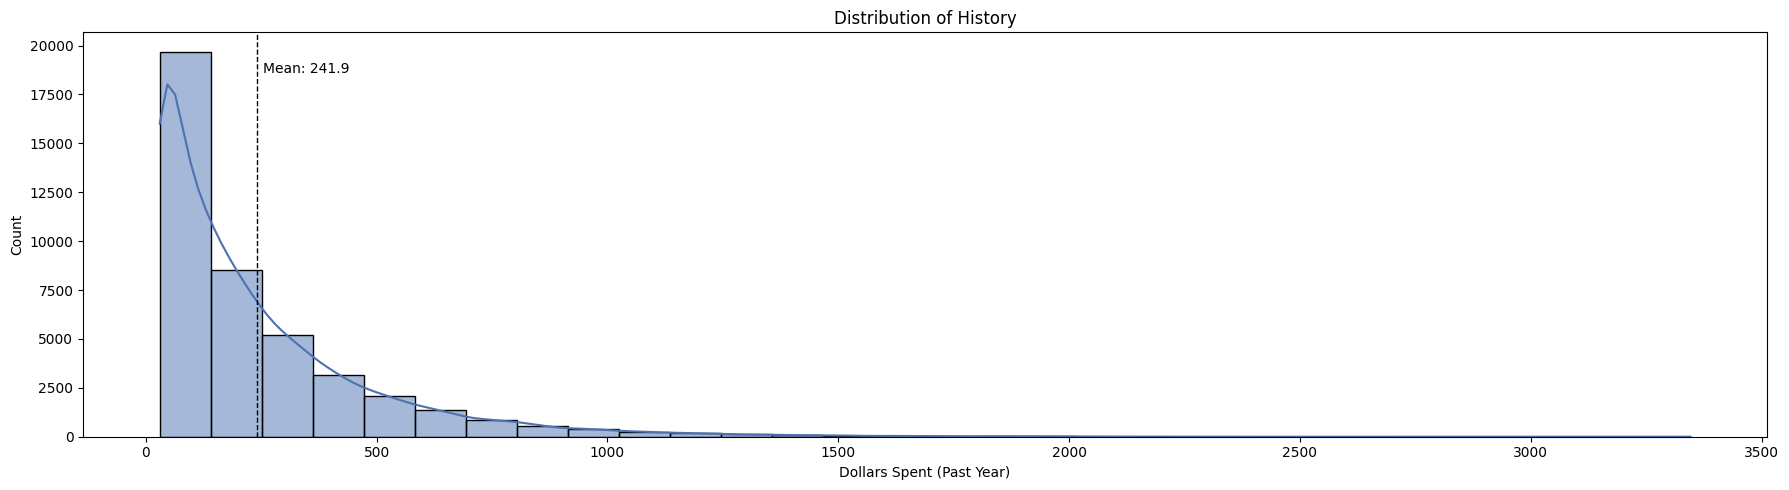

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Print the basic statistics for the history feature
print("Descriptive Statistics - History:\n")
print(df["history"].describe())

fig, ax = plt.subplots(1, 1, figsize=(18, 5))

# Plot a histogram showing the distribution of the history variable
sns.histplot(df["history"], kde = True, color = "#4C72B0", bins = 30, ax = ax)
    
# Calculate mean for annotation
mean_val = df["history"].mean()

ax.axvline(mean_val, color = "k", linestyle = "--", linewidth = 1)
ax.text(mean_val * 1.05, ax.get_ylim()[1] * 0.9, f"Mean: {mean_val:.1f}")

ax.set_title(f"Distribution of History")
ax.set_xlabel("Dollars Spent (Past Year)")

plt.tight_layout()
plt.show()

Next, I will generate bar charts showing the value counts for each categorical/discrete feature.

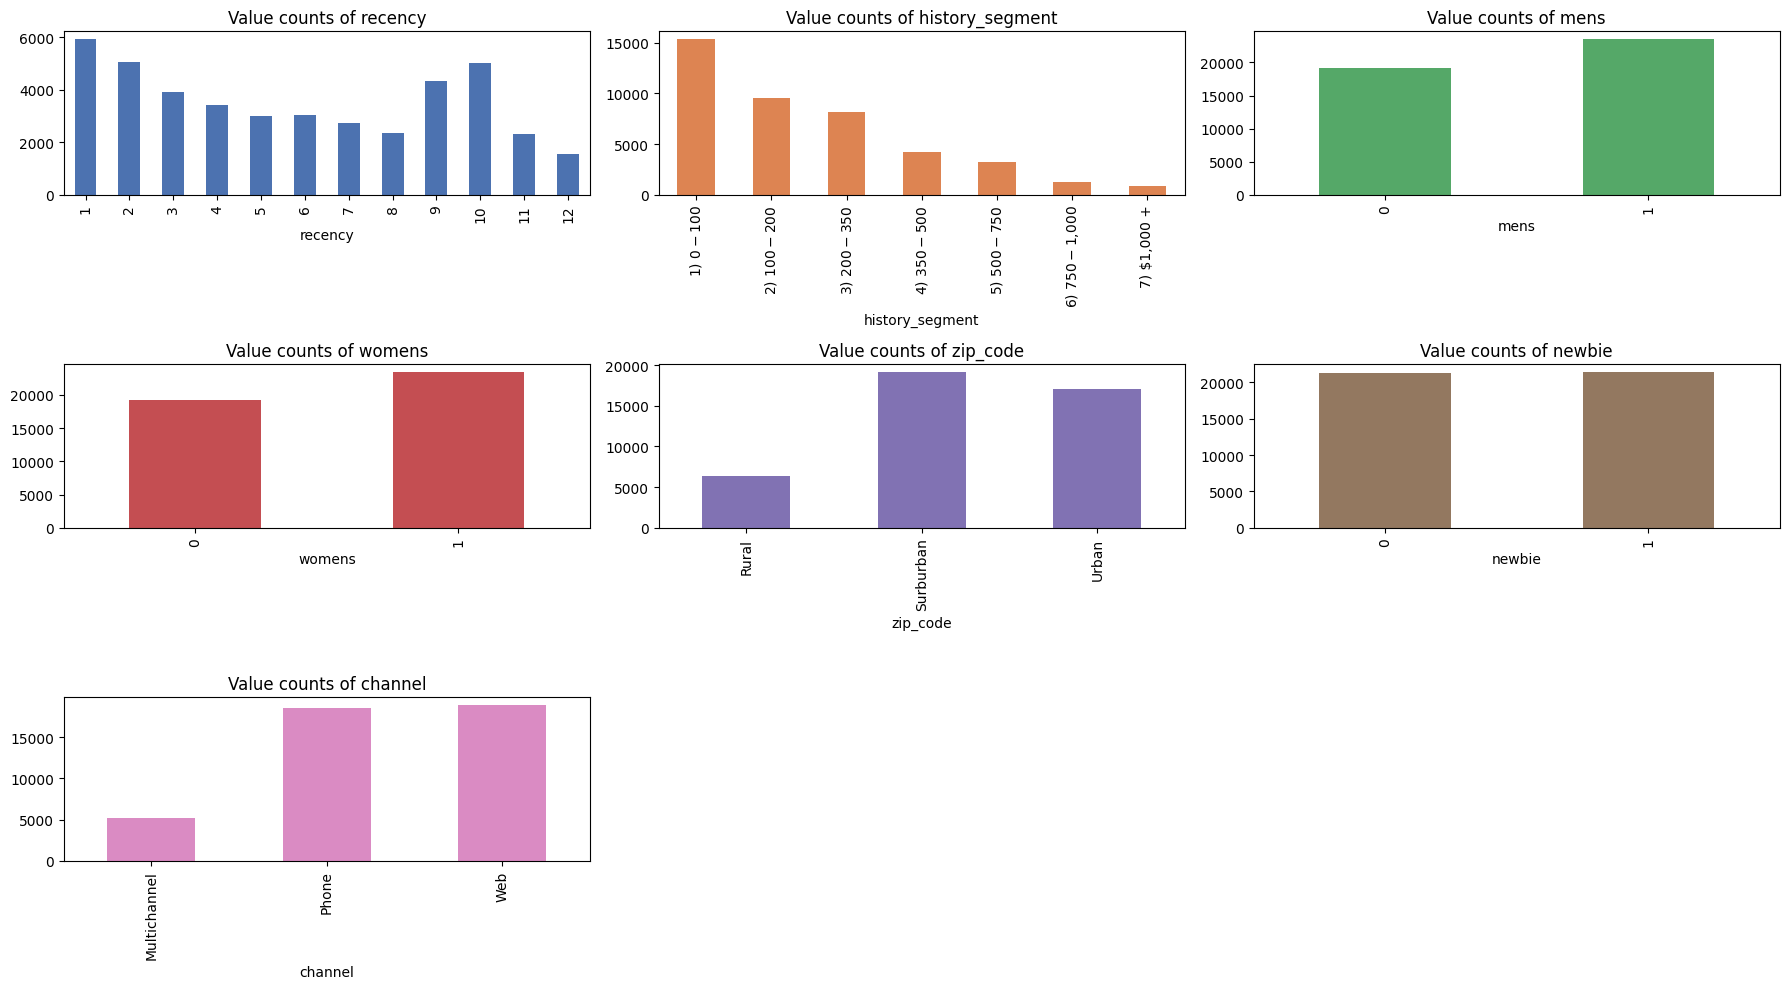

In [10]:
discrete_vars = [
    "recency", 
    "history_segment", 
    "mens", 
    "womens", 
    "zip_code", 
    "newbie", 
    "channel"
]

fig, axes = plt.subplots(3, 3, figsize=(18, 10))
axes = axes.flatten()  # Makes indexing easier: axes[0], axes[1], etc.

# The last two subplots will not be used, so hide them
axes[7].set_visible(False)
axes[8].set_visible(False)

colors = [
    "#4C72B0",  
    "#DD8452",  
    "#55A868",  
    "#C44E52",  
    "#8172B3",  
    "#937860",  
    "#DA8BC3",  
    "#8C8C8C"
]   

for i, var in enumerate(discrete_vars):
    df[var].value_counts().sort_index().plot.bar(title = f"Value counts of {var}", ax = axes[i], color = colors[i])

plt.tight_layout()
plt.show()

A few observations from these charts:

1. There is a typo in the zip_code values: "Surburban" should be "Suburban". 
2. By definition, history and history_segment seem to be measuring the same thing, and the history histogram and history_segment bar
chart both support this, suggesting a high level of multicollinearity between these features.
3. The history and history_segment charts also both show significant right skew.
4. The binary features (womens, mens, and newbie) all appear to be pretty well balanced.
5. However, the trinary features (channel and zip_code) both have one category with significantly fewer values than the other two.

I will address these observations one at a time:

#### #1 - Data Cleaning - zip_code typo

The code below corrects this typo.

In [11]:
df["zip_code"] = df["zip_code"].str.replace("Surburban", "Suburban")
# Confirm the spelling correction worked
print(df["zip_code"].unique())

['Rural' 'Urban' 'Suburban']


#### #2 - Multicollinearity of history and history_segment

Because history and history_segment appear to be multicollinear, I will drop one of them from the dataframe. Since history provides continuous granularity as opposed to the discrete categorization of history_segment, I will retain history and drop history_segment to preserve predictive resolution.

However, I am going to wait until I complete my data analysis before doing that, because having historical spending in a binned format will be helpful in some of the data analysis I want to perform below.

#### #3 - Right Skew of history

It is not surprising that the history feature is right-skewed, as this is often the case with spending data. The minimum amount that can be spent is always $0, but the maximum is theoretically unbounded. This makes it likely that a few heavy spenders will give the data a long right tail. This is more of an issue for linear models than for tree-based models, which are generally robust to skew. I plan to use both linear Logistic Regression models and tree-based LightGBM models. I could apply a log transform to this feature to address the skew, which would potentially benefit the Logistic Regression models. However, the outliers are not that severe, and applying such a transformation would make my results less intuitive. Consequently, I will leave this feature as is.

#### #4 - Balancing of Binary Features

The binary features are relatively well balanced. This is a positive, and no changes are needed.

#### #5 - Unbalanced Trinary Features

The unbalanced trinary features are less ideal, but for now, I am not going to make any changes to them. This is mainly an issue that needs to be kept in mind when interpreting my model. Uplift estimates for smaller groups tend to have wider confidence intervals, so if I see that when analyzing the results of my model, it is likely due to noise from the small sample size. Ultimately, though, the imbalance present in these features just reflects reality, and my model will need to learn that.

## Exploratory Data Analysis - Conversion Rates by Feature

Next, I want to calculate conversion rates for each individual feature.

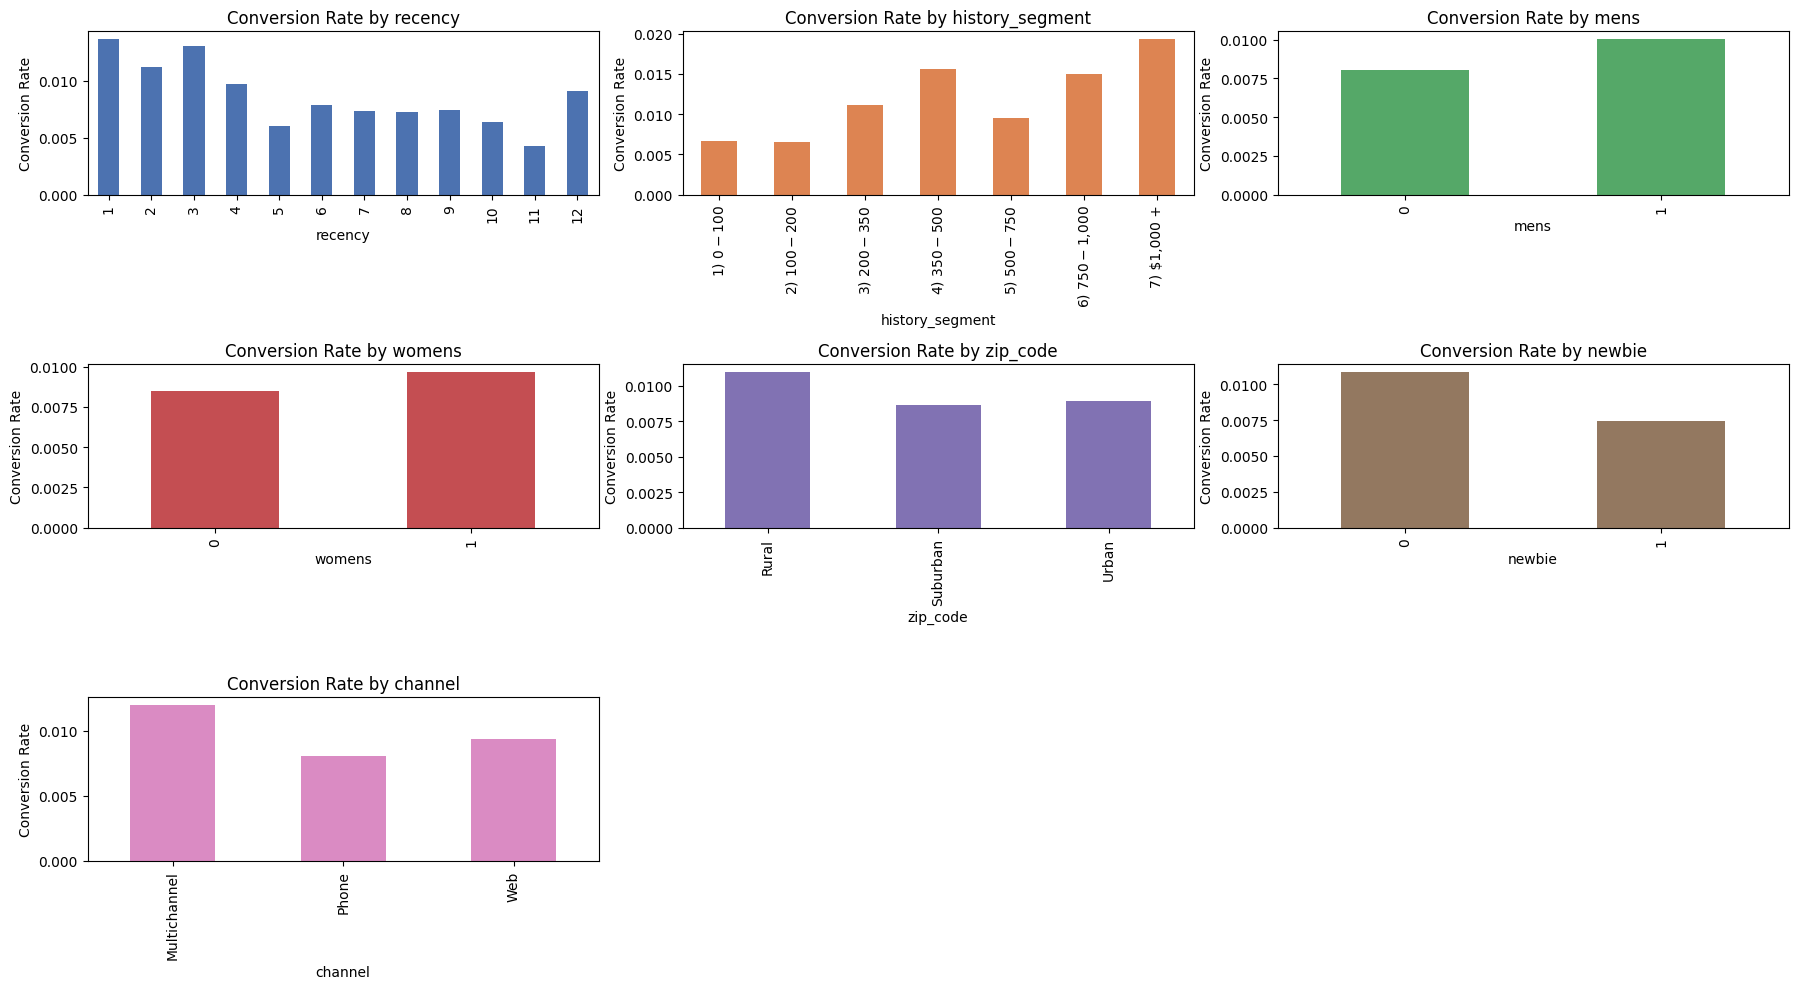

In [12]:
fig, axes = plt.subplots(3, 3, figsize=(18, 10))
axes = axes.flatten()
axes[7].set_visible(False)
axes[8].set_visible(False)

for i, var in enumerate(discrete_vars):
    conversion_rate = df.groupby(var)["conversion"].mean()
    conversion_rate.plot.bar(title=f"Conversion Rate by {var}", ax=axes[i], color=colors[i])
    axes[i].set_ylabel("Conversion Rate")

plt.tight_layout()
plt.show()

A few interesting observations about these charts:

1. Not surprisingly, customers who made purchases more recently were significantly more likely to be converted and purchase again.

2. Similarly, customers who spent more money in the past twelve months were much more likely to convert than those who spent less.

3. Although I'm focusing on the men's campaign, customers who purchased men's merchandise in the previous twelve months had a roughly equal conversion rate to customers who bought women's merchandise in the last twelve months.

4. Also, not surprisingly, returning customers were more likely to be converted than newbies.

5. Interestingly, customers who made purchases via both phone and the web in the previous twelve months were more likely to convert than those who purchased from only one channel. This could be because purchasing across multiple channels is correlated with more overall purchases, indicating customer loyalty.

I'd like to drill down a bit further into this and analyze conversion rates by feature and treatment.

## Exploratory Data Analysis - Conversion Rates by Feature and Treatment

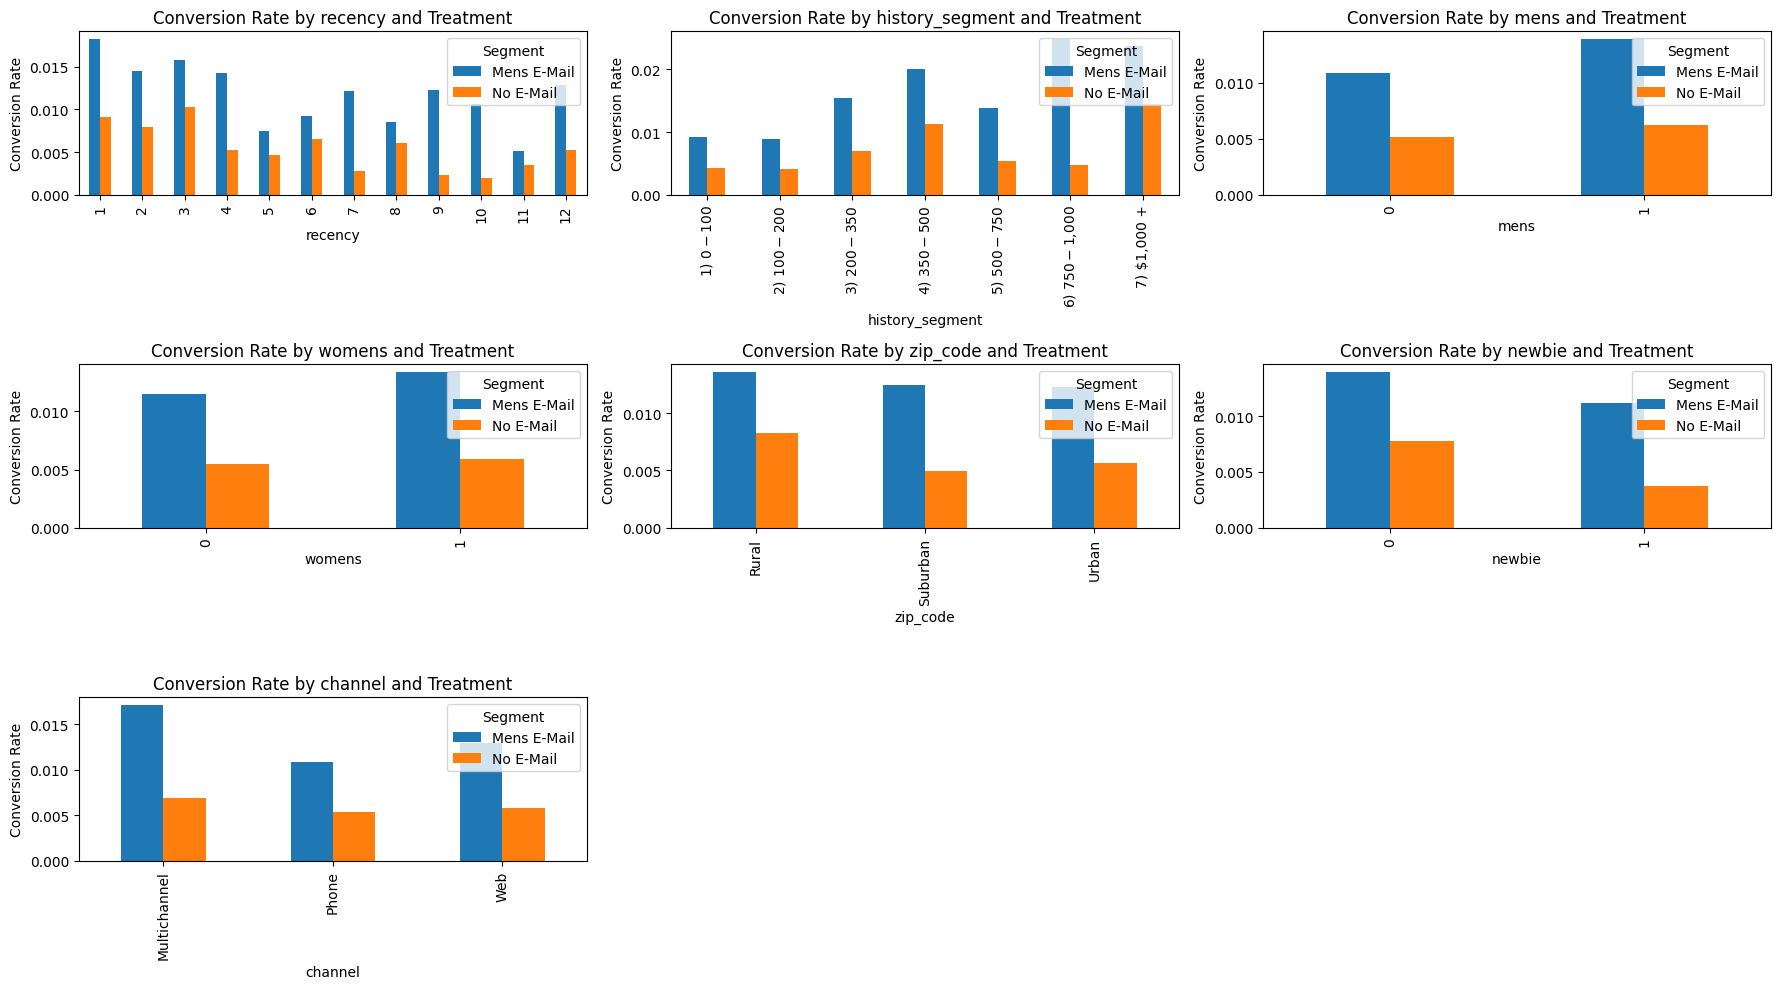

In [13]:
fig, axes = plt.subplots(3, 3, figsize=(18, 10))
axes = axes.flatten()
axes[7].set_visible(False)
axes[8].set_visible(False)

for i, var in enumerate(discrete_vars):
    conversion_rate = df.groupby([var, "segment"])["conversion"].mean().unstack()
    conversion_rate.plot.bar(title=f"Conversion Rate by {var} and Treatment", ax=axes[i])
    axes[i].set_ylabel("Conversion Rate")
    axes[i].legend(title="Segment", loc="upper right")

plt.tight_layout()
plt.show()

At first glance, these charts indicate that the email campaign had strong results across all customer segments. It appears to have been particularly successful at converting new customers and existing customers who had not purchased in several months.

## Exploratory Data Analysis - Overall Conversion Rate

Although the above feature-specific results indicate strong results for the treatment group compared to the control group, I also want to quickly check the overall conversion rate for the processed dataset.

In [14]:
print(df["conversion"].value_counts())

conversion
0    42224
1      389
Name: count, dtype: int64


This indicates that only 389 out of 42,613 customers were converted, for a conversion rate of less than 1%. This is extremely small. When I begin building the model, I will need to consider strategies like stratification to ensure I don't end up with a test set that contains few or no conversions.

## Exploratory Data Analysis - Correlation Matrix

Next, I will run a correlation heatmap to assess multicollinearity in the dataset. As discussed above, history and history_segment appear to be strongly multicollinear, but I hypothesize that the other features should not be strongly correlated with one another. However, if any pair of features correlates with an absolute value > 0.7, I will consider whether to include both in my model or remove one.

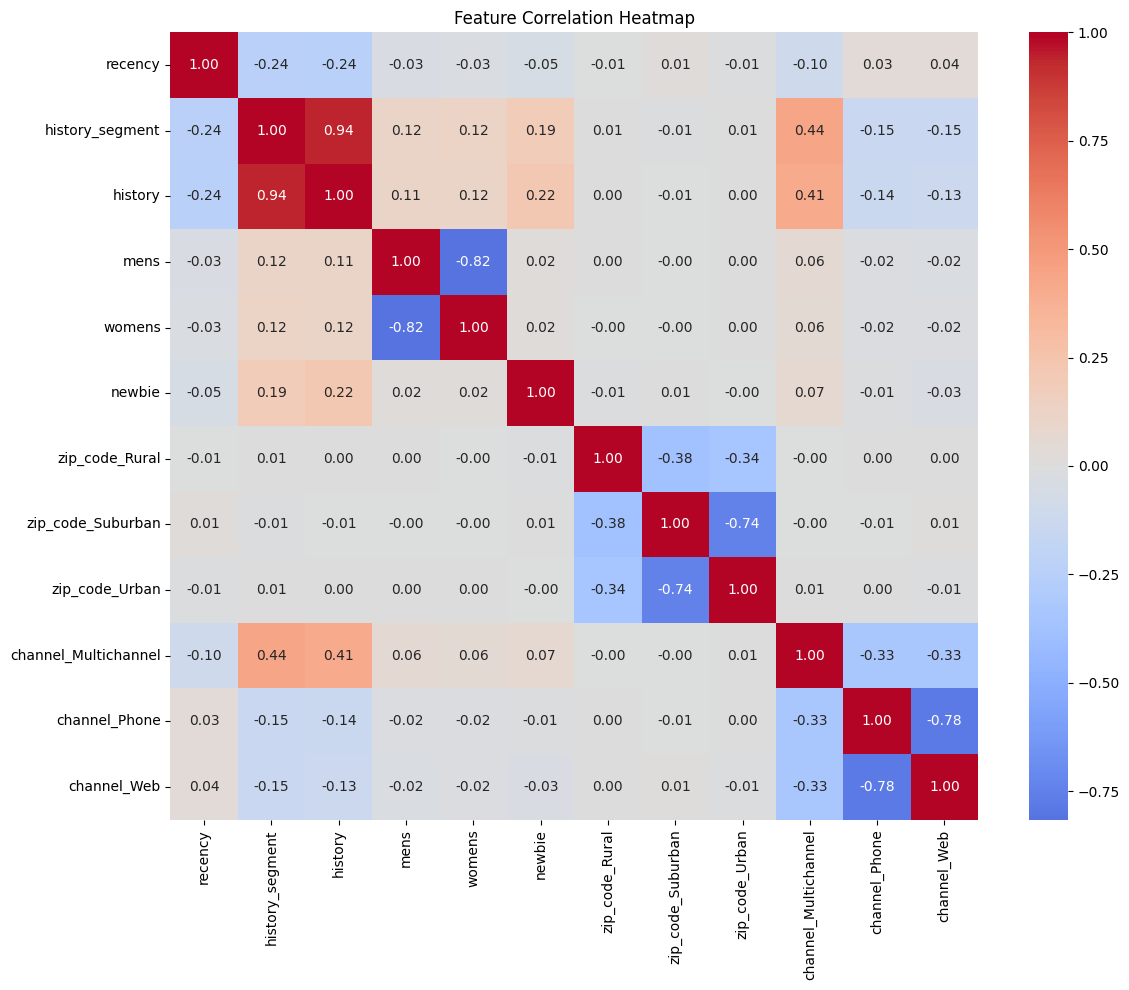

In [15]:
# I will use ordinal encoding for history_segment, so the below code maps the segments to the applicable number (zero-indexed)
history_order = {
    "1) $0 - $100": 0,
    "2) $100 - $200": 1,
    "3) $200 - $350": 2,
    "4) $350 - $500": 3,
    "5) $500 - $750": 4,
    "6) $750 - $1,000": 5,
    "7) $1,000 +": 6
}

# One-hot encode the categorical features
df_encoded = pd.get_dummies(df[features], columns=["zip_code", "channel"], drop_first=False) # No need to drop first for EDA
# Ordinal encode history_segment
df_encoded["history_segment"] = df["history_segment"].map(history_order)

# Create correlation matrix
corr_matrix = df_encoded.corr()

# Plot heatmap
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f", ax=ax)
ax.set_title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

As expected, history and history_segment are very strongly correlated. One of these features can be safely removed from the dataset without loss of information. As discussed above, I will remove history_segment to preserve the precision provided by the continuous history feature.

There are three other pairs of features where the absolute value of the correlation value is > 0.7:

1. mens and womens
2. channel_Phone and channel_Web
3. zip_code_Urban and zip_code_Suburban

However, I do not feel that these high correlation values justify removing either feature from any of these pairs. The negative correlation between the mens and womens features provides meaningful information about purchasing patterns that is worth including in my model. The high correlation between channel_Phone/channel_Web and zip_code_urban/zip_code_Suburban is just an artifact of one-hot encoding. These correlations simply reflect that these categories are mutually exclusive and are not indicative of true multicollinearity.

Thus, the only feature I will remove from the dataset is history_segment. I will do that now.

In [16]:
df = df.drop("history_segment", axis = 1)
# Remove history_segment from the features array and the discrete features array to ensure they continue to match the features 
# in the dataframe
features.remove("history_segment")
discrete_vars.remove("history_segment")
# Confirm that the columns remaining in the dataframe are as expected
print(df.columns)

Index(['recency', 'history', 'mens', 'womens', 'zip_code', 'newbie', 'channel',
       'segment', 'conversion'],
      dtype='object')


One further interesting note about the correlation heatmap is that the correlation between channel_Multichannel and the history and history_segment features supports my hypothesis above that purchasing through multiple channels indicates higher spend/more purchases overall. This at least partially explains why customers who made purchases through multiple channels were more likely to convert.

## Summary and Next Steps

### Key Findings
- The men's email campaign showed a stronger overall lift (0.68 pp) than the women's campaign (0.31 pp), so this analysis focuses on the men's campaign.
- Randomization was successful: treatment and control groups are well-balanced across all features.
- history_segment was removed due to near-perfect correlation (0.94) with history.
- No other multicollinearity issues require intervention.
- Initial exploration suggests the campaign was particularly effective for recent purchasers, new customers, and customers with higher historical spend.
- The overall conversion rate for the dataset was very low, necessitating the consideration of strategies to ensure a balanced train/test split.

### Preprocessing Applied
- Removed customers who received the women's email campaign (n = 21,387).
- Dropped visit and spend outcome variables (focusing on conversion).
- Corrected "Surburban" → "Suburban" typo in zip_code.
- Dropped history_segment (redundant with history).

### Dataset for Modeling
- **Records**: 42,613 (21,307 treatment + 21,306 control).
- **Features**: 7 (recency, history, mens, womens, zip_code, newbie, channel).
- **Treatment**: segment (binary: Mens E-Mail vs No E-Mail).
- **Outcome**: conversion (binary).

### Next Steps
Save the processed dataframe and proceed to baseline model implementation and uplift model development.

In [17]:
df.to_csv("../data/processed/hillstrom_mens_campaign.csv", index=False)